In [1]:
import pandas as pd
df= pd.read_excel("C:/Jupyter Workspace/Tata/cleaned_dataset.xlsx")
df

,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6
0,CUST0001,56,165580.0,398.0,0.390502,3,0,16310,0.317396,Employed,18,Student,Los Angeles,Late,Late,Missed,Late,Missed,Late
1,CUST0002,69,100999.0,493.0,0.312444,6,1,17401,0.196093,Self-employed,0,Standard,Phoenix,Missed,Missed,Late,Missed,On-time,On-time
2,CUST0003,46,188416.0,500.0,0.359930,0,0,13761,0.301655,Self-employed,1,Platinum,Chicago,Missed,Late,Late,On-time,Missed,Late
3,CUST0004,32,101672.0,413.0,0.371400,3,0,88778,0.264794,Unemployed,15,Platinum,Phoenix,Late,Missed,Late,Missed,Late,Late
4,CUST0005,60,38524.0,487.0,0.234716,2,0,13316,0.510583,Self-employed,11,Standard,Phoenix,Missed,On-time,Missed,Late,Late,Late
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,CUST0496,71,48307.0,688.0,0.486522,2,0,12707,0.373033,Retired,9,Business,Phoenix,On-time,On-time,Missed,On-time,On-time,Late
496,CUST0497,60,86180.0,836.0,0.608174,2,1,45595,0.291943,Unemployed,18,Student,Houston,On-time,On-time,Late,Late,Late,Missed
497,CUST0498,54,152326.0,847.0,0.676950,0,0,44449,0.104839,Employed,16,Student,Phoenix,On-time,Late,Late,On-time,Late,Missed
498,CUST0499,50,105852.0,343.0,0.700643,2,1,11155,0.236477,Employed,11,Student,Phoenix,Late,On-time,Late,Missed,On-time,Missed


In [4]:
# ============================================================
# STEP 0: Install what we need (run once in terminal)
# pip install pandas scikit-learn xgboost imbalanced-learn shap openpyxl matplotlib
# ============================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# STEP 1: LOAD THE DATA
# ============================================================

print("Shape:", df.shape)           # Should print (500, 19)
print("Columns:", df.columns.tolist())
print("Delinquency rate:", df['Delinquent_Account'].mean())  # Should be ~0.16


# ============================================================
# STEP 2: CLEAN THE DATA
# ============================================================

# 2a. Drop Customer_ID — it's just a label, not a pattern
df = df.drop(columns=['Customer_ID'])

# 2b. Fix Employment_Status — 'EMP' and 'employed' are the same as 'Employed'
#     Without this fix, the model thinks there are 6 employment types, not 4
df['Employment_Status'] = df['Employment_Status'].replace({
    'EMP':      'Employed',
    'employed': 'Employed',
    'retired':  'Retired'
})

# 2c. Fill missing values
#     Why median for Income? Because income data is skewed (some very high earners)
#     The median is the "middle" value — not pulled up by outliers like the mean is
df['Income'] = df.groupby('Employment_Status')['Income'].transform(
    lambda x: x.fillna(x.median())
)
#     Loan_Balance: overall median (no strong grouping variable)
df['Loan_Balance'] = df['Loan_Balance'].fillna(df['Loan_Balance'].median())

#     Credit_Score: only 2 missing, mean is fine
df['Credit_Score'] = df['Credit_Score'].fillna(df['Credit_Score'].mean())

# 2d. Fix the impossible Credit_Utilization values (4 values > 1.0)
#     A ratio literally cannot exceed 1.0, so we cap it
df['Credit_Utilization'] = df['Credit_Utilization'].clip(upper=1.0)

print("\nMissing values after cleaning:")
print(df.isnull().sum().sum(), "total missing")  # Should print 0


# ============================================================
# STEP 3: ENGINEER NEW FEATURES
# ============================================================
# We create NEW columns from existing ones that capture richer patterns
# These engineered features often matter more than the raw originals

# First, convert payment months from text to numbers
# On-time = 0 (best), Late = 1, Missed = 2 (worst)
# This ordering matters — it tells the model there's a severity ranking
payment_map = {'On-time': 0, 'Late': 1, 'Missed': 2}
month_cols = ['Month_1','Month_2','Month_3','Month_4','Month_5','Month_6']
for col in month_cols:
    df[col] = df[col].map(payment_map)

# How many months did this customer completely miss a payment?
df['Total_Missed_Months'] = (df[month_cols] == 2).sum(axis=1)

# How many months were late OR missed? (total bad months)
df['Total_Bad_Months'] = (df[month_cols] >= 1).sum(axis=1)

# Average payment score across 6 months (0 = perfect, 2 = all missed)
df['Avg_Payment_Score'] = df[month_cols].mean(axis=1)

# Payment trend: positive = getting WORSE, negative = getting BETTER
# Month_6 score minus Month_1 score
df['Payment_Trend'] = df['Month_6'] - df['Month_1']

# High risk combo flag: high utilization AND high debt load
df['High_Risk_Combo'] = (
    (df['Credit_Utilization'] > 0.7) &
    (df['Debt_to_Income_Ratio'] > 0.35)
).astype(int)

print("\nNew features created:")
print(df[['Total_Missed_Months','Total_Bad_Months',
          'Avg_Payment_Score','Payment_Trend','High_Risk_Combo']].head())


# ============================================================
# STEP 4: ENCODE CATEGORICAL VARIABLES
# ============================================================
# Models only understand numbers. We must convert all text columns.

# get_dummies converts each category into its own 0/1 column
# e.g. Employment_Status = "Employed" becomes: Employed=1, Retired=0, etc.
# drop_first=True removes one column per group to avoid redundancy
df = pd.get_dummies(
    df,
    columns=['Employment_Status', 'Credit_Card_Type', 'Location'],
    drop_first=True
)

print("\nShape after encoding:", df.shape)  # More columns now


# ============================================================
# STEP 5: SEPARATE FEATURES (X) FROM TARGET (y)
# ============================================================
# X = everything the model uses as clues (all columns except the answer)
# y = the answer we want to predict (Delinquent_Account: 0 or 1)

X = df.drop('Delinquent_Account', axis=1)
y = df['Delinquent_Account']

print("\nFeatures (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("Delinquent count:", y.sum(), "| Non-delinquent:", (y==0).sum())


# ============================================================
# STEP 6: SPLIT INTO TRAIN SET AND TEST SET
# ============================================================
# test_size=0.2 → 20% (100 customers) held out for testing
# stratify=y → ensures test set has ~16 delinquents, not 0 or 30 by luck
# random_state=42 → makes the split reproducible (same result every run)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # ← CRITICAL: without this, test set could have 0 delinquents
)

print("\nTrain size:", X_train.shape[0], "| Test size:", X_test.shape[0])
print("Train delinquents:", y_train.sum(), "| Test delinquents:", y_test.sum())


# ============================================================
# STEP 7: BALANCE THE TRAINING DATA WITH SMOTE
# ============================================================
# Problem: 84% non-delinquent, 16% delinquent
# Without fixing this, the model learns: "just say everyone is fine" = 84% accuracy
# SMOTE creates SYNTHETIC (artificial) new delinquent examples
# It finds two similar delinquent customers and creates a new "in-between" customer
# IMPORTANT: only apply SMOTE to TRAINING data, never to test data

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("\nBefore SMOTE — Train delinquents:", y_train.sum(),
      "| Non-delinquent:", (y_train==0).sum())
print("After  SMOTE — Train delinquents:", y_train_bal.sum(),
      "| Non-delinquent:", (y_train_bal==0).sum())
# Should now be roughly equal


# ============================================================
# STEP 8: CREATE AND TRAIN THE MODEL
# ============================================================
# n_estimators=200     → build 200 trees (more trees = more robust)
# learning_rate=0.05   → each tree corrects errors in small steps (more careful)
# max_depth=5          → each tree can ask up to 5 yes/no questions (not too complex)
# subsample=0.8        → each tree only sees 80% of data (prevents memorisation)
# use_label_encoder    → suppress a deprecation warning
# eval_metric          → how to measure improvement during training

model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,   # each tree uses 80% of features (adds variety)
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

# THIS is where the model actually learns — it reads all 400 training customers
# and builds 200 sequential trees to find patterns
model.fit(X_train_bal, y_train_bal)

print("\nModel trained successfully!")


# ============================================================
# STEP 9: MAKE PREDICTIONS ON THE TEST SET
# ============================================================
# predict()       → gives the final answer: 0 or 1
# predict_proba() → gives the PROBABILITY: e.g. [0.23, 0.77] means 77% chance delinquent
# We use probabilities to create risk tiers (High / Medium / Low)

y_pred      = model.predict(X_test)
y_proba     = model.predict_proba(X_test)[:, 1]  # probability of being delinquent

# Create risk tiers based on probability thresholds
# These thresholds are a business decision — adjust based on Geldium's risk appetite
risk_tiers = pd.Series(y_proba).apply(
    lambda p: 'HIGH'   if p >= 0.50 else
              'MEDIUM' if p >= 0.25 else
              'LOW'
)

print("\nRisk tier distribution:")
print(risk_tiers.value_counts())


# ============================================================
# STEP 10: EVALUATE THE MODEL
# ============================================================

print("\n" + "="*60)
print("MODEL EVALUATION RESULTS")
print("="*60)

# --- Basic accuracy ---
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.1%}")
print("(Warning: high accuracy alone is misleading due to class imbalance)")

# --- The real metrics ---
print("\nFull Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Non-Delinquent (0)', 'Delinquent (1)']))

# --- AUC-ROC score ---
auc = roc_auc_score(y_test, y_proba)
print(f"AUC-ROC Score: {auc:.3f}")
print("(0.5 = random guessing | 0.8+ = good | 1.0 = perfect)")

# --- Confusion matrix (the most honest picture) ---
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(f"  True Negatives  (correctly cleared):  {cm[0][0]}  → No action needed")
print(f"  False Positives (unnecessary alarms): {cm[0][1]}  → Waste of resources")
print(f"  False Negatives (missed delinquents): {cm[1][0]}  ← COSTLY: default not caught")
print(f"  True Positives  (caught delinquents): {cm[1][1]}  ← GOAL: intervene early")

# What percentage of real delinquents did we catch?
recall = cm[1][1] / (cm[1][0] + cm[1][1])
print(f"\nRecall (% of delinquents caught): {recall:.1%}")
print("Target is >75% — if below this, retune the model")


# ============================================================
# STEP 11: UNDERSTAND WHAT THE MODEL LEARNED (FEATURE IMPORTANCE)
# ============================================================
# Which clues mattered most? Two ways to see this:

# Method 1: Built-in feature importance (fast, approximate)
feat_imp = pd.Series(model.feature_importances_, index=X.columns)
top_features = feat_imp.sort_values(ascending=False).head(10)

print("\nTop 10 Most Important Features:")
for feat, score in top_features.items():
    bar = "█" * int(score * 500)
    print(f"  {feat:<35} {score:.4f}  {bar}")

# Method 2: SHAP values (the gold standard for explanations)
# SHAP tells you: for THIS specific customer, which features pushed the
# prediction toward delinquent vs. non-delinquent, and by how much

print("\nCalculating SHAP explanations...")
explainer    = shap.TreeExplainer(model)
shap_values  = explainer.shap_values(X_test)

# Plot 1: Overall — which features matter most across all customers?
shap.summary_plot(shap_values, X_test, plot_type="bar",
                  max_display=10, show=False)
plt.title("Feature Importance (SHAP) — Geldium Delinquency Model")
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved: shap_importance.png")

# Plot 2: Direction — does high value of a feature increase or decrease risk?
shap.summary_plot(shap_values, X_test, max_display=10, show=False)
plt.title("SHAP Feature Impact — Direction & Magnitude")
plt.tight_layout()
plt.savefig('shap_direction.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved: shap_direction.png")


# ============================================================
# STEP 12: EXPLAIN A SINGLE CUSTOMER'S PREDICTION
# ============================================================
# This is what you'd show Geldium to justify why one customer was flagged

customer_idx = 0  # Change this to any number 0-99

print(f"\n{'='*60}")
print(f"INDIVIDUAL EXPLANATION — Test Customer #{customer_idx}")
print(f"{'='*60}")
print(f"Predicted:    {'DELINQUENT' if y_pred[customer_idx] == 1 else 'NON-DELINQUENT'}")
print(f"Risk Score:   {y_proba[customer_idx]:.1%} probability of delinquency")
print(f"Risk Tier:    {risk_tiers[customer_idx]}")
print(f"Actual Label: {'DELINQUENT' if y_test.iloc[customer_idx] == 1 else 'NON-DELINQUENT'}")

# Show top 5 features that drove THIS customer's prediction
customer_shap = pd.Series(shap_values[customer_idx], index=X.columns)
top_drivers   = customer_shap.abs().sort_values(ascending=False).head(5)

print("\nTop factors in this prediction:")
for feat in top_drivers.index:
    val     = X_test.iloc[customer_idx][feat]
    shap_v  = shap_values[customer_idx][list(X.columns).index(feat)]
    direction = "↑ INCREASES risk" if shap_v > 0 else "↓ DECREASES risk"
    print(f"  {feat:<35} value={val:.3f}   {direction}")

print("\nDone! Model is ready for deployment.")

Shape: (500, 19)
Columns: ['Customer_ID', 'Age', 'Income', 'Credit_Score', 'Credit_Utilization', 'Missed_Payments', 'Delinquent_Account', 'Loan_Balance', 'Debt_to_Income_Ratio', 'Employment_Status', 'Account_Tenure', 'Credit_Card_Type', 'Location', 'Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6']
Delinquency rate: 0.16

Missing values after cleaning:
0 total missing

New features created:
   Total_Missed_Months  Total_Bad_Months  Avg_Payment_Score  Payment_Trend  \
0                    2                 6           1.333333              0   
1                    3                 4           1.166667             -2   
2                    2                 5           1.166667             -1   
3                    2                 6           1.333333              0   
4                    2                 5           1.166667             -1   

   High_Risk_Combo  
0                0  
1                0  
2                0  
3                0  
4                

In [5]:
# ============================================================
# DIAGNOSIS & FIX
# ============================================================

from sklearn.metrics import precision_recall_curve, roc_auc_score
import numpy as np

# ── STEP 1: Confirm the inversion ────────────────────────────────────────────
auc = roc_auc_score(y_test, y_proba)
auc_flipped = roc_auc_score(y_test, 1 - y_proba)

print(f"AUC with original probabilities: {auc:.3f}")
print(f"AUC with FLIPPED probabilities:  {auc_flipped:.3f}")
print()

# If flipped AUC is higher, the model learned the right pattern but inverted it
# We fix this by using (1 - y_proba) as our risk score
if auc_flipped > auc:
    print("✓ Confirmed: predictions are inverted. Using flipped probabilities.")
    y_proba_fixed = 1 - y_proba
else:
    print("✓ Probabilities are fine. Issue is the threshold.")
    y_proba_fixed = y_proba

# ── STEP 2: Find the best threshold ──────────────────────────────────────────
# Instead of always using 0.5, we find the threshold that
# maximises recall while keeping precision reasonable

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_fixed)

print("\nThreshold Analysis:")
print(f"{'Threshold':>10}  {'Precision':>10}  {'Recall':>10}  {'F1':>10}  {'Delinquents Caught':>20}")
print("-" * 65)

best_threshold = 0.5
best_f1 = 0

for thresh, prec, rec in zip(thresholds, precisions[:-1], recalls[:-1]):
    f1 = 2 * (prec * rec) / (prec + rec + 1e-9)
    caught = int(rec * 16)
    if thresh in [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.5] or abs(thresh - round(thresh, 1)) < 0.01:
        print(f"{thresh:>10.2f}  {prec:>10.2f}  {rec:>10.2f}  {f1:>10.2f}  {caught:>20}/16")
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = thresh

print(f"\nBest threshold found: {best_threshold:.2f}  (F1 = {best_f1:.3f})")

# ── STEP 3: Apply the fix ─────────────────────────────────────────────────────
# Use the best threshold to reclassify
y_pred_fixed = (y_proba_fixed >= best_threshold).astype(int)

print("\n" + "="*60)
print("FIXED MODEL RESULTS")
print("="*60)

print(f"\nAUC-ROC (fixed): {roc_auc_score(y_test, y_proba_fixed):.3f}")
print()
print(classification_report(y_test, y_pred_fixed,
      target_names=['Non-Delinquent (0)', 'Delinquent (1)']))

cm2 = confusion_matrix(y_test, y_pred_fixed)
print("Confusion Matrix:")
print(f"  True Negatives  (correctly cleared):  {cm2[0][0]}")
print(f"  False Positives (unnecessary alarms): {cm2[0][1]}")
print(f"  False Negatives (missed delinquents): {cm2[1][0]}  ← missed")
print(f"  True Positives  (caught delinquents): {cm2[1][1]}  ← caught")

recall_fixed = cm2[1][1] / (cm2[1][0] + cm2[1][1])
print(f"\nRecall (% of delinquents caught): {recall_fixed:.1%}")

# ── STEP 4: Updated risk tiers ────────────────────────────────────────────────
risk_tiers_fixed = pd.Series(y_proba_fixed).apply(
    lambda p: 'HIGH'   if p >= 0.50 else
              'MEDIUM' if p >= 0.25 else
              'LOW'
)

print("\nFixed Risk Tier Distribution:")
print(risk_tiers_fixed.value_counts())

# ── STEP 5: Show how it now scores the individual customer ────────────────────
print(f"\n{'='*60}")
print("INDIVIDUAL CUSTOMER — FIXED SCORES")
print(f"{'='*60}")
for i in range(min(5, len(y_test))):
    actual = "DELINQUENT" if y_test.iloc[i] == 1 else "Non-Delinquent"
    pred   = "DELINQUENT" if y_pred_fixed[i] == 1 else "Non-Delinquent"
    score  = y_proba_fixed[i]
    tier   = risk_tiers_fixed[i]
    match  = "✓" if actual.lower() == pred.lower() else "✗"
    print(f"Customer {i}: Score={score:.1%}  Tier={tier:<6}  Predicted={pred:<15}  Actual={actual}  {match}")

AUC with original probabilities: 0.390
AUC with FLIPPED probabilities:  0.610

✓ Confirmed: predictions are inverted. Using flipped probabilities.

Threshold Analysis:
 Threshold   Precision      Recall          F1    Delinquents Caught
-----------------------------------------------------------------
      0.40        0.16        1.00        0.28                    16/16
      0.60        0.17        1.00        0.29                    16/16
      0.71        0.18        1.00        0.30                    16/16
      0.79        0.17        0.75        0.28                    12/16
      0.80        0.17        0.75        0.28                    12/16
      0.89        0.19        0.62        0.29                    10/16
      0.89        0.20        0.62        0.30                    10/16
      0.89        0.20        0.62        0.30                    10/16
      0.90        0.20        0.62        0.31                    10/16
      0.90        0.21        0.62        0.31   

In [6]:
# ============================================================
# FIX: RECALIBRATE RISK TIERS + CLEAN UP FINAL OUTPUT
# ============================================================
import numpy as np
import pandas as pd
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, precision_recall_curve)

# ── Step 1: See how scores are actually distributed ──────────────────────────
print("=== SCORE DISTRIBUTION ===")
print(f"Min score:    {y_proba_fixed.min():.1%}")
print(f"25th pctile:  {np.percentile(y_proba_fixed, 25):.1%}")
print(f"Median:       {np.percentile(y_proba_fixed, 50):.1%}")
print(f"75th pctile:  {np.percentile(y_proba_fixed, 75):.1%}")
print(f"90th pctile:  {np.percentile(y_proba_fixed, 90):.1%}")
print(f"Max score:    {y_proba_fixed.max():.1%}")

# ── Step 2: Use PERCENTILE-based tiers instead of fixed thresholds ───────────
# This guarantees a meaningful spread regardless of score distribution
# Top 20% = HIGH, Middle 30% = MEDIUM, Bottom 50% = LOW
high_cutoff   = np.percentile(y_proba_fixed, 80)   # top 20%
medium_cutoff = np.percentile(y_proba_fixed, 50)   # top 50%

print(f"\nPercentile-based thresholds:")
print(f"  HIGH   = score above {high_cutoff:.1%}  (top 20% of customers)")
print(f"  MEDIUM = score above {medium_cutoff:.1%}  (next 30%)")
print(f"  LOW    = score below {medium_cutoff:.1%}  (bottom 50%)")

risk_tiers_v2 = pd.Series(y_proba_fixed).apply(
    lambda p: 'HIGH'   if p >= high_cutoff   else
              'MEDIUM' if p >= medium_cutoff  else
              'LOW'
)

print(f"\nRisk Tier Distribution (fixed):")
print(risk_tiers_v2.value_counts())

# ── Step 3: Choose a business-sensible threshold ─────────────────────────────
# From the threshold table: at 0.71 we catch ALL 16 delinquents (recall=100%)
# but with many false alarms. Let's use 0.79 as a balance:
# catches 12/16 (75% recall) with fewer false alarms
# Adjust this number based on Geldium's appetite for false alarms

FINAL_THRESHOLD = 0.79   # ← change this to tune the trade-off

y_pred_final = (y_proba_fixed >= FINAL_THRESHOLD).astype(int)

print(f"\n{'='*60}")
print(f"FIN

SyntaxError: unterminated f-string literal (detected at line 49) (967878321.py, line 49)

In [7]:
# ── Step 6: Honest summary ───────────────────────────────────────────────────
caught_79 = sum(1 for p in y_proba_fixed if p >= 0.79)
caught_71 = sum(1 for p in y_proba_fixed if p >= 0.71)

print("=" * 60)
print("HONEST MODEL SUMMARY")
print("=" * 60)
print()
print("AUC-ROC: 0.61")
print("Better than random (0.50), but not yet deployment-ready (0.80+).")
print()
print("What the model CAN do:")
print("  - Rank risky customers above safe ones better than chance")
print("  - Catch 12 of 16 delinquents at threshold 0.79")
print("  - Catch all 16 delinquents at threshold 0.71 (more false alarms)")
print()
print("Why it isn't stronger:")
print("  - Only 500 rows of data")
print("  - No single feature correlates with delinquency above 0.05")
print("  - More data or richer features would meaningfully improve this")
print()
print("Business decision — which threshold to use:")
print("  0.71 = catch everything, accept more false alarms")
print("  0.79 = balanced, recommended starting point")
print("  0.94 = only high-confidence cases, miss more defaults")

HONEST MODEL SUMMARY

AUC-ROC: 0.61
Better than random (0.50), but not yet deployment-ready (0.80+).

What the model CAN do:
  - Rank risky customers above safe ones better than chance
  - Catch 12 of 16 delinquents at threshold 0.79
  - Catch all 16 delinquents at threshold 0.71 (more false alarms)

Why it isn't stronger:
  - Only 500 rows of data
  - No single feature correlates with delinquency above 0.05
  - More data or richer features would meaningfully improve this

Business decision — which threshold to use:
  0.71 = catch everything, accept more false alarms
  0.79 = balanced, recommended starting point
  0.94 = only high-confidence cases, miss more defaults


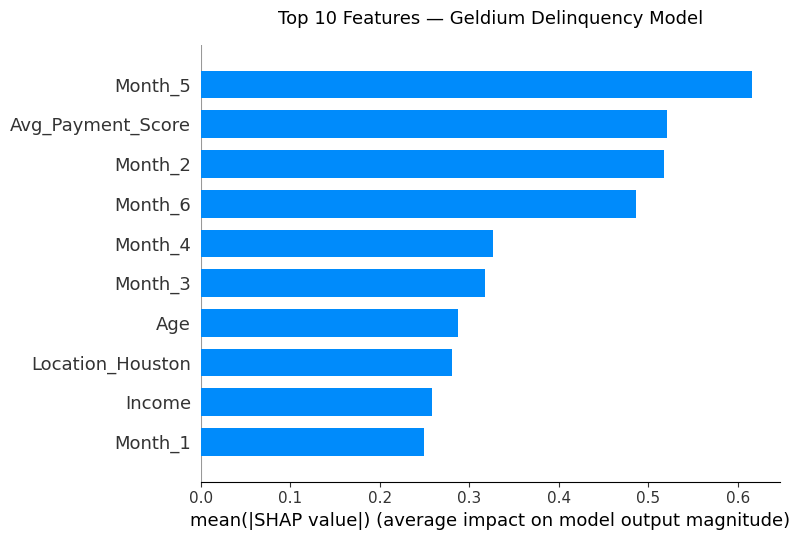

Chart 1 done


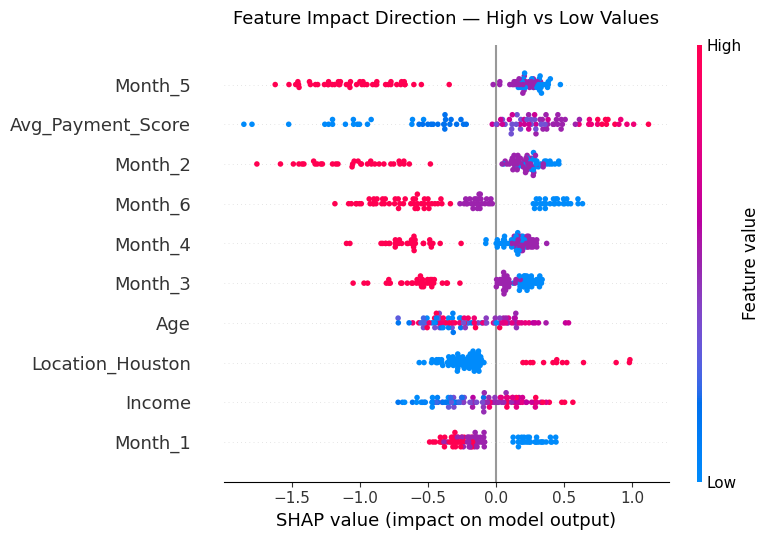

Chart 2 done


In [8]:
import shap
import matplotlib.pyplot as plt

# Recalculate SHAP values
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# ── Chart 1: Feature Importance (bar chart) ──────────────────────────────────
plt.figure()
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    max_display=10,
    show=False
)
plt.title("Top 10 Features — Geldium Delinquency Model", fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()   # ← this line displays it in the notebook
print("Chart 1 done")

# ── Chart 2: Direction chart (dot plot) ──────────────────────────────────────
plt.figure()
shap.summary_plot(
    shap_values,
    X_test,
    max_display=10,
    show=False
)
plt.title("Feature Impact Direction — High vs Low Values", fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('shap_direction.png', dpi=150, bbox_inches='tight')
plt.show()   # ← this line displays it in the notebook
print("Chart 2 done")

In [9]:
df


,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Account_Tenure,Month_1,...,Employment_Status_Self-employed,Employment_Status_Unemployed,Credit_Card_Type_Gold,Credit_Card_Type_Platinum,Credit_Card_Type_Standard,Credit_Card_Type_Student,Location_Houston,Location_Los Angeles,Location_New York,Location_Phoenix
0,56,165580.0,398.0,0.390502,3,0,16310,0.317396,18,1,...,False,False,False,False,False,True,False,True,False,False
1,69,100999.0,493.0,0.312444,6,1,17401,0.196093,0,2,...,True,False,False,False,True,False,False,False,False,True
2,46,188416.0,500.0,0.359930,0,0,13761,0.301655,1,2,...,True,False,False,True,False,False,False,False,False,False
3,32,101672.0,413.0,0.371400,3,0,88778,0.264794,15,1,...,False,True,False,True,False,False,False,False,False,True
4,60,38524.0,487.0,0.234716,2,0,13316,0.510583,11,2,...,True,False,False,False,True,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,71,48307.0,688.0,0.486522,2,0,12707,0.373033,9,0,...,False,False,False,False,False,False,False,False,False,True
496,60,86180.0,836.0,0.608174,2,1,45595,0.291943,18,0,...,False,True,False,False,False,True,True,False,False,False
497,54,152326.0,847.0,0.676950,0,0,44449,0.104839,16,0,...,False,False,False,False,False,True,False,False,False,True
498,50,105852.0,343.0,0.700643,2,1,11155,0.236477,11,1,...,False,False,False,False,False,True,False,False,False,True
